In [7]:
import numpy as np
import matplotlib.pyplot as plt
# from scripts.utils import vpt_smape, vpt_nrmse, vpt_mse, smape_rolling
from scipy.spatial.distance import cdist
from dysts.systems import get_attractor_list
from dysts.flows import __dict__ as flow_models
from dysts.analysis import gp_dim
from dysts.metrics import estimate_kl_divergence
import os

plt.rcParams["font.family"] = "Helvetica"

In [19]:
average_vpt = dict()
median_vpt = dict()
average_smape = dict()
median_smape = dict()

average_vpt_2 = dict()
median_vpt_2 = dict()
average_smape_2 = dict()
median_smape_2 = dict()

average_cdim = dict()
median_cdim = dict()
average_kl = dict()
median_kl = dict()

average_mse = dict()
median_mse = dict()
average_mae = dict()
median_mae = dict()

In [17]:
granularity = 30
#context_lengths = 2**np.arange(6, 14)
context_lengths = 2**np.arange(6, 11)
forecast_length = 300
#simulation_length = 10000
simulation_length = 100000
rolling_window = context_lengths[-1]
num_ic = 20

# Directory to store trajectories
#trajectory_dir = "trajectories"
trajectory_dir = "../data/long_trajectories"


# equation_names = get_attractor_list()
# equation_names.remove('FluidTrampoline')
# equation_names.remove('HyperLu')
# equation_names.remove('SprottMore')
# equation_names.remove('StickSlipOscillator')
#equation_names = equation_names[:2]

import torch
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')
# from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
# from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
# from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model


sys.path.append('../benchmark/')
from metrics import vpt_smape, smape_rolling


def mse(y_true, y_pred):
    
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

def mse_rolling(ts1, ts2):

    n = min(ts1.shape[0], ts2.shape[0])
    all_mse = list()
    for i in range(1, n+1):
        mse_val = mse(ts1[:i], ts2[:i])
        all_mse.append(mse_val)

    return np.array(all_mse)

def mae(y_true, y_pred):
    
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

def mae_rolling(ts1, ts2):

    n = min(ts1.shape[0], ts2.shape[0])
    all_mae = list()
    for i in range(1, n+1):
        mae_val = mae(ts1[:i], ts2[:i])
        all_mae.append(mae_val)

    return np.array(all_mae)

In [ ]:
import glob

average_vpt = np.load(f'../analysis/dynamix_statistics/average_vpt.npy',allow_pickle='TRUE').item()
# found_systems = np.unique([item[0] for item in average_vpt.keys()])

for trajectory in sorted(glob.glob("../data/long_trajectories/*.npy")):
    equation_name = trajectory.split("/")[-1].split(".")[0]
    print(equation_name, flush=True)
    # if equation_name in found_systems:
    #     print(f"Skipping {equation_name} because it's already in the found_systems list", flush=True)
    #     continue
    
    traj = np.load(trajectory, allow_pickle=True)
    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)

    try:
        for context_length in context_lengths:

            all_vpt = list() # collecting all vpt for the parroting model
            all_smape_rolling = list() # collecting all smape values across time
            all_vpt_2 = list() # collecting all vpt for the parroting model
            all_smape_rolling_2 = list() # collecting all smape values across time
            all_cdim = list() # collecting all correlation dimensions
            all_kl_dist = list() # collecting all kl divergence values
            all_mse_rolling = list()
            all_mae_rolling = list()

            for i in range(0, len(traj)-context_length-forecast_length, rolling_window):
                if i < rolling_window*num_ic:
                    #print(i//rolling_window)
                    traj_context = traj[i:i+context_length,:]
                    traj_true = traj[i+context_length:i+context_length+forecast_length,:]
                    traj_pred_full = np.zeros_like(traj_true)

                    # Load the pre-trained model
                    model = load_hf_model("dynamix-3d-alrnn-v1.0")
                    model.eval() # Set model to evaluation mode
                    forecaster = DynaMixForecaster(model) # Initialize the forecaster
                    ## Make DynaMix prediction
                    context_traj_tensor  = torch.tensor(traj_context)
                    with torch.no_grad(): 
                        reconstruction = forecaster.forecast(
                            context=context_traj_tensor,
                            horizon=forecast_length, # Match the horizon of the ground truth
                            standardize=True,
                        )
                    # reconstruction = torch.transpose(reconstruction, 0, 1)
                    traj_pred_full = reconstruction.detach().numpy()

                    for dim in range(traj_true.shape[1]):
                        traj_pred = traj_pred_full[:, dim]

                        vpt = vpt_smape(traj_pred, traj_true[:, dim]) / granularity
                        smape_val = np.array(smape_rolling(traj_true[:, dim], traj_pred))

                        all_vpt.append(vpt)
                        all_smape_rolling.append(smape_val)

                        mse_val = mse_rolling(traj_true[:, dim], traj_pred)
                        all_mse_rolling.append(mse_val)
                        
                        mae_val = mae_rolling(traj_true[:, dim], traj_pred)
                        all_mae_rolling.append(mae_val)


                    vpt = vpt_smape(traj_pred_full.squeeze(), traj_true.squeeze()) / granularity
                    smape_val = np.array(smape_rolling(traj_true, traj_pred_full))
                    all_vpt_2.append(vpt)
                    all_smape_rolling_2.append(smape_val)
                    
                    kl_dist = estimate_kl_divergence(traj_true, traj_pred_full)
                    if np.isinf(kl_dist):
                        kl_dist = np.nan
                    all_kl_dist.append(kl_dist)

                    cdim_pred = gp_dim(traj_pred_full)
                    cdim_true = gp_dim(traj_true)
                    all_cdim.append(np.array([cdim_pred, cdim_true]))

            average_vpt[(equation_name,context_length)] = np.mean(all_vpt)
            median_vpt[(equation_name,context_length)] = np.median(all_vpt)
            average_smape[(equation_name,context_length)] = np.mean(all_smape_rolling, axis=0)
            median_smape[(equation_name,context_length)] = np.median(all_smape_rolling, axis=0)

            average_vpt_2[(equation_name,context_length)] = np.mean(all_vpt_2)
            median_vpt_2[(equation_name,context_length)] = np.median(all_vpt_2)
            average_smape_2[(equation_name,context_length)] = np.mean(all_smape_rolling_2, axis=0)
            median_smape_2[(equation_name,context_length)] = np.median(all_smape_rolling_2, axis=0)

            average_cdim[(equation_name,context_length)] = np.mean(all_cdim, axis=0)
            median_cdim[(equation_name,context_length)] = np.median(all_cdim, axis=0)
            average_kl[(equation_name,context_length)] = np.nanmean(all_kl_dist)
            median_kl[(equation_name,context_length)] = np.nanmedian(all_kl_dist)

            average_mse[(equation_name,context_length)] = np.mean(all_mse_rolling, axis=0)
            median_mse[(equation_name,context_length)] = np.median(all_mse_rolling, axis=0)
            average_mae[(equation_name,context_length)] = np.mean(all_mae_rolling, axis=0)
            median_mae[(equation_name,context_length)] = np.median(all_mae_rolling, axis=0)

    except Exception as e:
        print(e)
        print(f"Skipping {equation_name}", flush=True)
        continue


Aizawa
AnishchenkoAstakhov
Arneodo
Skipping Arneodo because it's already in the found_systems list
ArnoldBeltramiChildress
Skipping ArnoldBeltramiChildress because it's already in the found_systems list
ArnoldWeb
Skipping ArnoldWeb because it's already in the found_systems list
AtmosphericRegime
Skipping AtmosphericRegime because it's already in the found_systems list
BeerRNN
BelousovZhabotinsky
BickleyJet
Skipping BickleyJet because it's already in the found_systems list
Blasius
Skipping Blasius because it's already in the found_systems list
BlinkingRotlet
Skipping BlinkingRotlet because it's already in the found_systems list
BlinkingVortex
Skipping BlinkingVortex because it's already in the found_systems list
Bouali
Skipping Bouali because it's already in the found_systems list
Bouali2
Skipping Bouali2 because it's already in the found_systems list
BurkeShaw
Skipping BurkeShaw because it's already in the found_systems list
CaTwoPlus
CaTwoPlusQuasiperiodic
CellCycle
Skipping CellCycle

/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/numpy/_core/function_base.py:140: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))


ForcedVanDerPol
Skipping ForcedVanDerPol because it's already in the found_systems list
GenesioTesi
Skipping GenesioTesi because it's already in the found_systems list
GlycolyticOscillation
Skipping GlycolyticOscillation because it's already in the found_systems list
GuckenheimerHolmes
Skipping GuckenheimerHolmes because it's already in the found_systems list
Hadley
Skipping Hadley because it's already in the found_systems list
Halvorsen
Skipping Halvorsen because it's already in the found_systems list
HastingsPowell
HenonHeiles
Skipping HenonHeiles because it's already in the found_systems list
HindmarshRose
Skipping HindmarshRose because it's already in the found_systems list
Hopfield
Skipping Hopfield because it's already in the found_systems list
HyperBao
HyperCai
HyperJha
Skipping HyperJha because it's already in the found_systems list
HyperLorenz
HyperPang
Skipping HyperPang because it's already in the found_systems list
HyperQi
HyperRossler
HyperWang
Skipping HyperWang because i

/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: divide by zero encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: overflow encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))


zero-size array to reduction operation minimum which has no identity
Skipping PanXuZhou
PehlivanWei
Skipping PehlivanWei because it's already in the found_systems list
PiecewiseCircuit
Qi
QiChen
RabinovichFabrikant
Skipping RabinovichFabrikant because it's already in the found_systems list
RayleighBenard
Skipping RayleighBenard because it's already in the found_systems list
RikitakeDynamo
Rossler
Skipping Rossler because it's already in the found_systems list
Rucklidge
Skipping Rucklidge because it's already in the found_systems list
Sakarya
Skipping Sakarya because it's already in the found_systems list
SaltonSea
SanUmSrisuchinwong
Skipping SanUmSrisuchinwong because it's already in the found_systems list
ScrollDelay
Skipping ScrollDelay because it's already in the found_systems list
ShimizuMorioka
SprottA
SprottB
SprottC
SprottD
SprottDelay
Skipping SprottDelay because it's already in the found_systems list
SprottE
SprottF
Skipping SprottF because it's already in the found_systems li

/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


WangSun
Skipping WangSun because it's already in the found_systems list
WindmiReduced
YuWang
Skipping YuWang because it's already in the found_systems list
YuWang2
ZhouChen
Skipping ZhouChen because it's already in the found_systems list


In [40]:
np.save(f'../analysis/dynamix_statistics/average_vpt.npy', average_vpt)
np.save(f'../analysis/dynamix_statistics/median_vpt.npy', median_vpt) 
np.save(f'../analysis/dynamix_statistics/average_smape.npy', average_smape)
np.save(f'../analysis/dynamix_statistics/median_smape.npy', median_smape)
np.save(f'../analysis/dynamix_statistics/average_vpt_2.npy', average_vpt_2)
np.save(f'../analysis/dynamix_statistics/median_vpt_2.npy', median_vpt_2) 
np.save(f'../analysis/dynamix_statistics/average_smape_2.npy', average_smape_2)
np.save(f'../analysis/dynamix_statistics/median_smape_2.npy', median_smape_2)
np.save(f'../analysis/dynamix_statistics/average_cdim.npy', average_cdim)
np.save(f'../analysis/dynamix_statistics/median_cdim.npy', median_cdim)
np.save(f'../analysis/dynamix_statistics/average_kl.npy', average_kl)
np.save(f'../analysis/dynamix_statistics/median_kl.npy', median_kl)
np.save(f'../analysis/dynamix_statistics/average_mse.npy', average_mse)
np.save(f'../analysis/dynamix_statistics/median_mse.npy', median_mse)
np.save(f'../analysis/dynamix_statistics/average_mae.npy', average_mae)
np.save(f'../analysis/dynamix_statistics/median_mae.npy', median_mae)

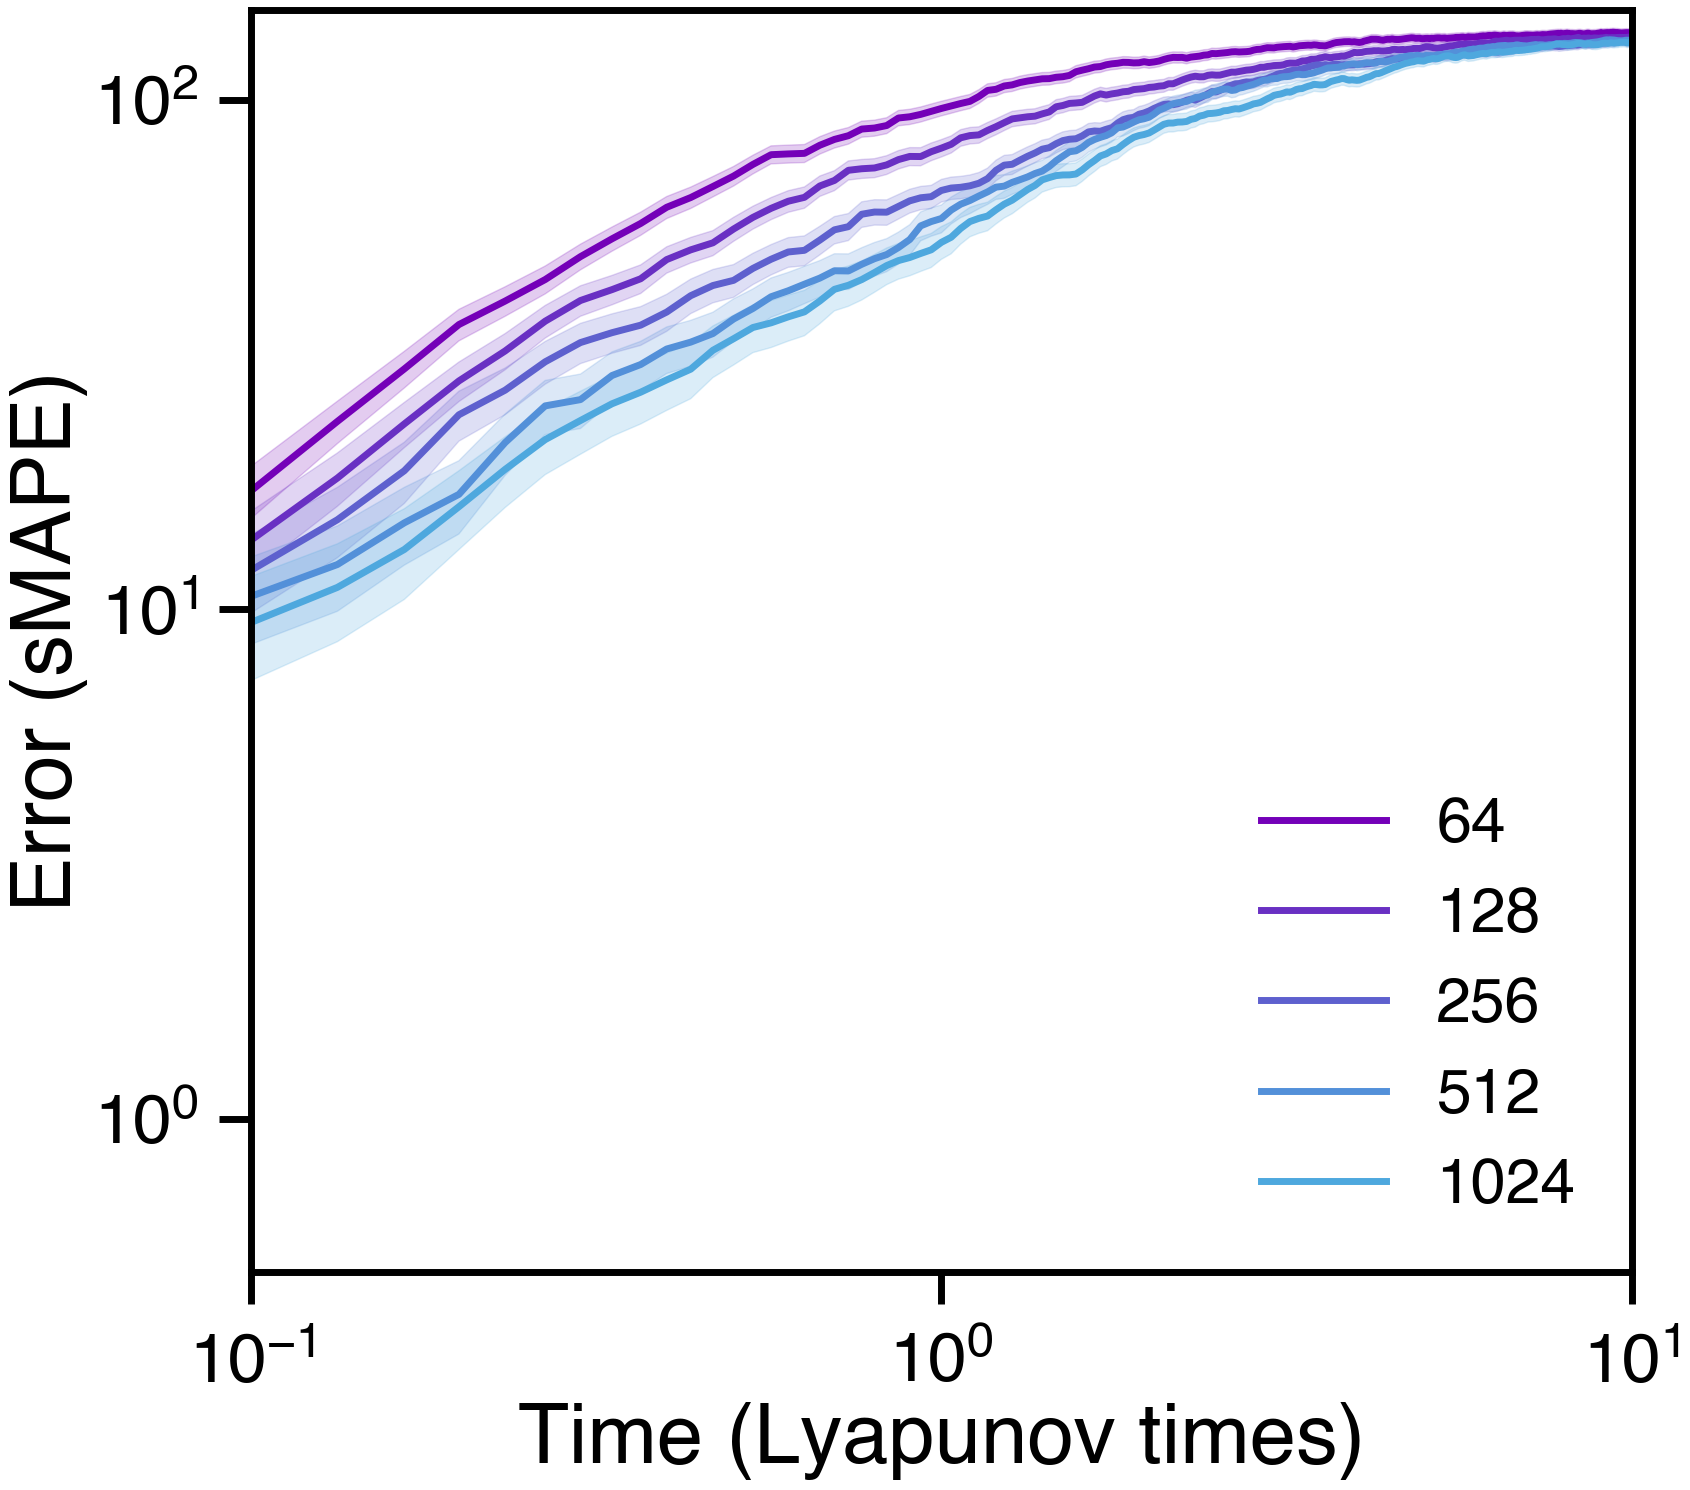

In [46]:
#import degas as dg
colors = ['#f94144', '#f3722c', '#f8961e', '#f9844a', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590', '#277da1']
colors = ["#7400b8","#6930c3","#5e60ce","#5390d9","#4ea8de","#48bfe3","#56cfe1","#64dfdf","#72efdd","#80ffdb"]

time = np.arange(1/granularity, (forecast_length+1)/granularity, 1/granularity)

equation_names = np.unique([item[0] for item in median_smape.keys()])

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Time (Lyapunov times)', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error (sMAPE)', fontname="Helvetica", fontsize = 60)
  
for i, context_length in enumerate(context_lengths):
  smape_trjs = [median_smape[(equation_name, context_length)] for equation_name, ctx in median_smape.keys() if ctx == context_length]
  smape_trj = np.median(smape_trjs, axis=0)
  smape_std = np.std(smape_trjs, axis=0)/np.sqrt(len(equation_names))
  plt.plot(time, smape_trj, lw=5, ls='-', alpha=1, color=colors[i], label=context_length)
  ax.fill_between(time, smape_trj - smape_std, smape_trj + smape_std, alpha=0.2, color=colors[i])
  #dg.plot_err(smape_trj, smape_std/1.0, x=time, color=colors[i], label=context_length, zorder=10*i)

plt.xscale('log')
plt.yscale('log')

plt.xlim([.1, 10])
plt.ylim([.5, 150])

plt.legend(loc='lower right', frameon=False, prop={'size':45}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'smape_rolling_chronos.pdf', bbox_inches='tight')